In [1]:
# Data processing
import pandas as pd
import numpy as np

# Machine learning
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Model saving
import joblib

# Visualization
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\daily_business_sales.csv"
)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(1885, 22)


,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,...,snap_CA,snap_TX,snap_WI,lag_7,lag_28,rolling_mean_7,rolling_mean_28,day_of_week,week,is_event
0,d_29,29908,2011-02-26,11105,Saturday,1,2,2011,NaN,NaN,...,0,0,0,31689.0,32631.0,24143.142857,26238.678571,5,8,0
1,d_30,28707,2011-02-27,11105,Sunday,2,2,2011,NaN,NaN,...,0,0,0,29283.0,31749.0,23888.714286,26141.428571,6,8,0
2,d_31,21240,2011-02-28,11105,Monday,3,2,2011,NaN,NaN,...,0,0,0,23966.0,23783.0,23806.428571,26032.785714,0,9,0
3,d_32,22872,2011-03-01,11105,Tuesday,4,3,2011,NaN,NaN,...,1,1,0,20501.0,25412.0,23417.000000,25941.964286,1,9,0
4,d_33,22046,2011-03-02,11105,Wednesday,5,3,2011,NaN,NaN,...,1,0,1,20757.0,19146.0,23755.714286,25851.250000,2,9,0


In [3]:
features = [
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "day_of_week",
    "month",
    "week",
    "year",
    "is_event",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

target = "sales"

In [4]:
train_df = df.iloc[:-30]
test_df = df.iloc[-30:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [5]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
preds = model.predict(X_test)

In [7]:
results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": preds
})

results.head()

,Actual,Predicted
0,53863,47274.136719
1,46360,45396.636719
2,36041,38460.937500
3,33857,35465.445312
4,32359,35571.949219


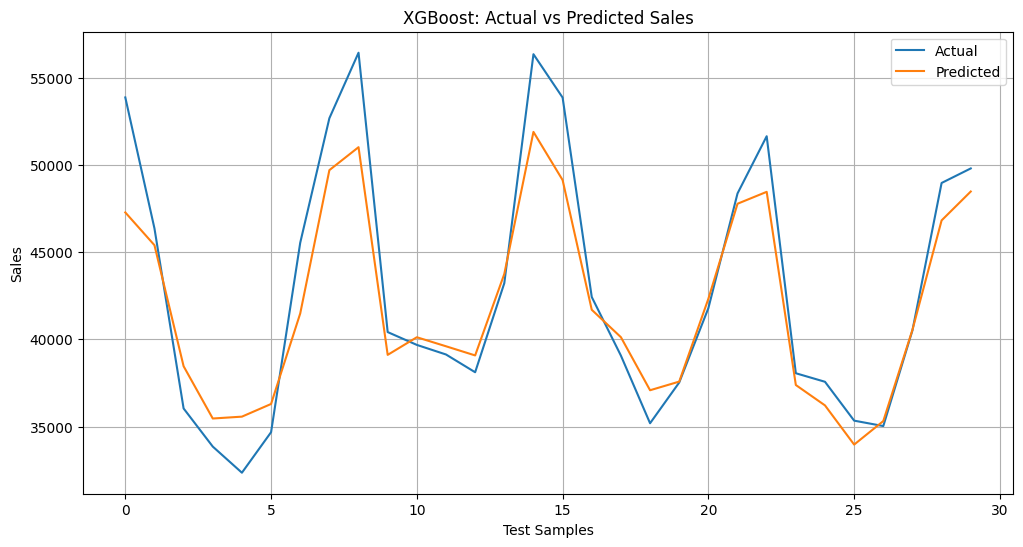

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    preds,
    label="Predicted"
)

plt.title(
    "XGBoost: Actual vs Predicted Sales"
)

plt.xlabel("Test Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

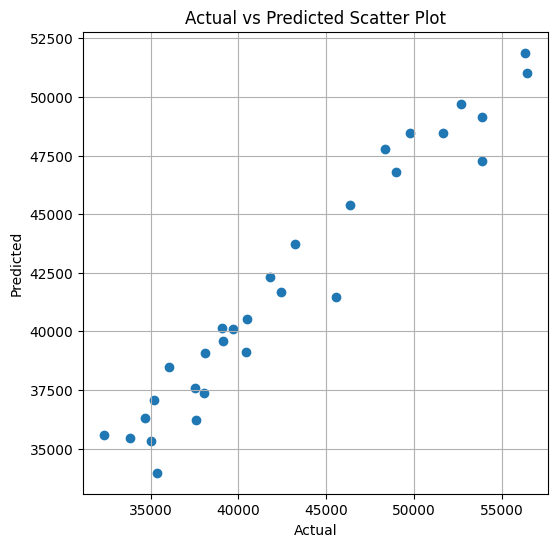

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    preds
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Scatter Plot"
)

plt.grid(True)

plt.show()

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

mape = mean_absolute_percentage_error(
    y_test,
    preds
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 1898.9271240234375
RMSE: 2532.5092299930516
MAPE: 4.209451377391815


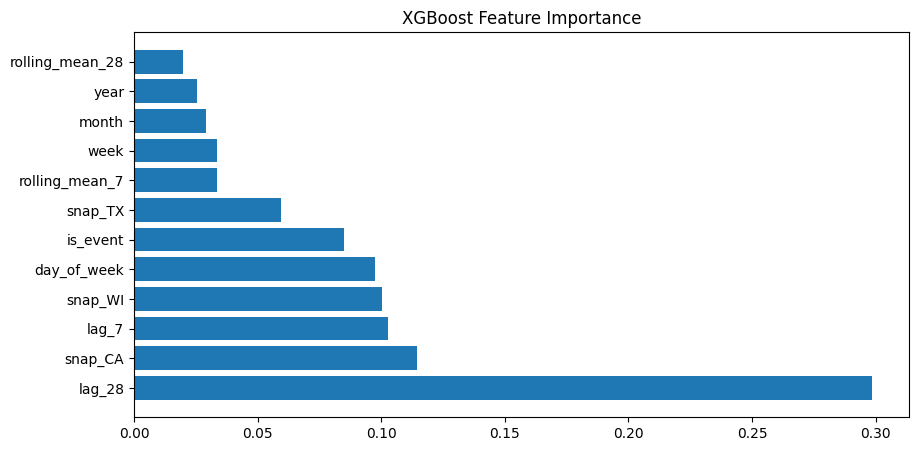

In [11]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.show()

In [12]:
import joblib

joblib.dump(
    model,
    r"C:\Users\91991\Desktop\internships\AMDOX\models\forecasting\xgboost_forecast.pkl"
)

['C:\\Users\\91991\\Desktop\\internships\\AMDOX\\models\\forecasting\\xgboost_forecast.pkl']

In [13]:
results = test_df[
    ["date", "sales"]
].copy()

results["prediction"] = preds

results.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\xgboost_predictions.csv",
    index=False
)